In [0]:
# Common imports
import os
import pandas as pd
import numpy as np
from sklearn import preprocessing
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.random import seed
from tensorflow import set_random_seed

from keras.layers import Input, Dropout
from keras.layers.core import Dense 
from keras.models import Model, Sequential, load_model
from keras import regularizers
from keras.models import model_from_json

Using TensorFlow backend.


In [0]:
df = pd.read_csv('ranfle.csv')

df['Date-Time'] = df['Date-Time'].astype('datetime64[ns]')
df.drop('health', axis=1, inplace=True)
df.set_index('Date-Time', inplace=True)

df.head()

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17
Date-Time,,,,,,,,,,,,
2018-06-28 18:06:00,57.588474,6377.601074,9.804532,552.471697,50.607209,385.276244,148.974045,96.442593,151.858002,152.548477,151.922577,756.466190
2018-06-28 20:12:00,61.615921,6449.225098,13.639497,594.623535,55.382072,418.773707,148.974045,98.525002,151.858002,152.548477,151.922577,922.316956
2018-06-28 20:15:00,61.615921,6449.225098,13.639497,594.623535,54.733008,419.794830,148.974045,97.271492,151.858002,152.548477,151.922577,922.316956
2018-06-28 20:18:00,61.615921,6449.225098,13.639497,594.623535,54.941535,419.374949,148.974045,97.271492,151.858002,152.548477,151.922577,923.484897
2018-06-28 20:21:00,61.615921,6449.225098,13.639497,594.623535,55.098432,419.934536,148.974045,97.271492,151.858002,152.548477,151.922577,932.327881


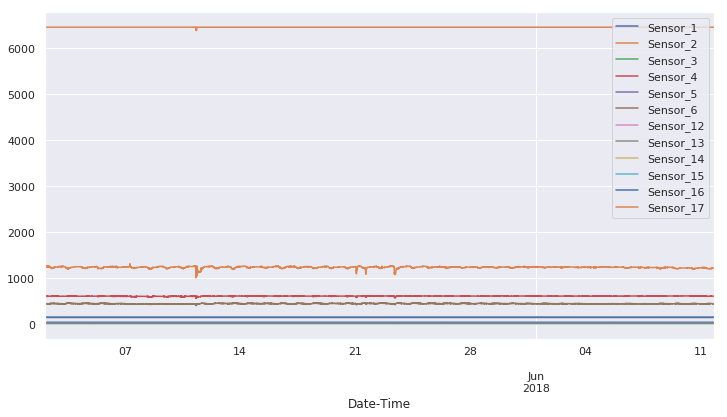

In [0]:
cut_point = '2018-06-11 20:18:00'

dataset_train = df[:cut_point]
dataset_test = df[cut_point:]
dataset_train.plot(figsize = (12,6))

In [0]:
scaler = preprocessing.MinMaxScaler()

X_train = pd.DataFrame(scaler.fit_transform(dataset_train), 
                              columns=dataset_train.columns, 
                              index=dataset_train.index)
# Random shuffle training data
X_train.sample(frac=1)

X_test = pd.DataFrame(scaler.transform(dataset_test), 
                             columns=dataset_test.columns, 
                             index=dataset_test.index)

In [0]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, svd_solver= 'full')
X_train_PCA = pca.fit_transform(X_train)
X_train_PCA = pd.DataFrame(X_train_PCA)
X_train_PCA.index = X_train.index

X_test_PCA = pca.transform(X_test)
X_test_PCA = pd.DataFrame(X_test_PCA)
X_test_PCA.index = X_test.index

In [0]:
def cov_matrix(data, verbose=False):
    covariance_matrix = np.cov(data, rowvar=False)
    if is_pos_def(covariance_matrix):
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        if is_pos_def(inv_covariance_matrix):
            return covariance_matrix, inv_covariance_matrix
        else:
            print("Error: Inverse of Covariance Matrix is not positive definite!")
    else:
        print("Error: Covariance Matrix is not positive definite!")

def MahalanobisDist(inv_cov_matrix, mean_distr, data, verbose=False):
    inv_covariance_matrix = inv_cov_matrix
    vars_mean = mean_distr
    diff = data - vars_mean
    md = []
    for i in range(len(diff)):
        md.append(np.sqrt(diff[i].dot(inv_covariance_matrix).dot(diff[i])))
    return md
  
def MD_threshold(dist, extreme=False, verbose=False):
    k = 3. if extreme else 2.
    threshold = np.mean(dist) * k
    return threshold
  
def is_pos_def(A):
    if np.allclose(A, A.T):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def MD_detectOutliers(dist, extreme=False, verbose=False):
    k = 3. if extreme else 2.
    threshold = np.mean(dist) * k
    outliers = []
    for i in range(len(dist)):
        if dist[i] >= threshold:
            outliers.append(i)  # index of the outlier
    return np.array(outliers)

In [0]:
data_train = np.array(X_train_PCA.values)
data_test = np.array(X_test_PCA.values)

In [0]:
cov_matrix, inv_cov_matrix  = cov_matrix(data_train)
mean_distr = data_train.mean(axis=0)

In [0]:
dist_test = MahalanobisDist(inv_cov_matrix, mean_distr, data_test, verbose=False)
dist_train = MahalanobisDist(inv_cov_matrix, mean_distr, data_train, verbose=False)
threshold = MD_threshold(dist_train, extreme = True)

(0.0, 15)

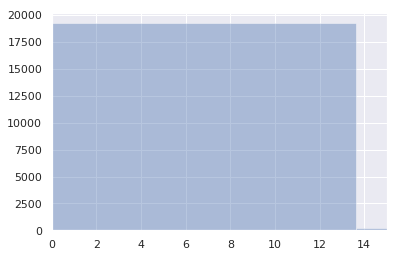

In [0]:
plt.figure()
sns.distplot(np.square(dist_train),
             bins = 10, 
             kde= False);
plt.xlim([0.0,15])

Text(0.5, 0, 'Mahalanobis dist')

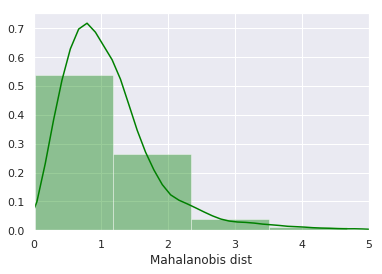

In [0]:
plt.figure()
sns.distplot(dist_train,
             bins = 10, 
             kde= True, 
            color = 'green');
plt.xlim([0.0,5])
plt.xlabel('Mahalanobis dist')

In [0]:
anomaly_train = pd.DataFrame()
anomaly_train['Mob dist']= dist_train
anomaly_train['Thresh'] = threshold
# If Mob dist above threshold: Flag as anomaly
anomaly_train['Anomaly'] = anomaly_train['Mob dist'] > anomaly_train['Thresh']
anomaly_train.index = X_train_PCA.index
anomaly = pd.DataFrame()
anomaly['Mob dist']= dist_test
anomaly['Thresh'] = threshold
# If Mob dist above threshold: Flag as anomaly
anomaly['Anomaly'] = anomaly['Mob dist'] > anomaly['Thresh']
anomaly.index = X_test_PCA.index
anomaly.head()

,Mob dist,Thresh,Anomaly
Date-Time,,,
2018-06-11 20:18:00,0.760915,3.425341,False
2018-06-11 20:21:00,0.507408,3.425341,False
2018-06-11 20:24:00,1.174115,3.425341,False
2018-06-11 20:27:00,0.728886,3.425341,False
2018-06-11 20:30:00,0.496545,3.425341,False


In [0]:
anomaly_alldata = pd.concat([anomaly_train, anomaly])
anomaly_alldata.to_csv('Anomaly_distance.csv')

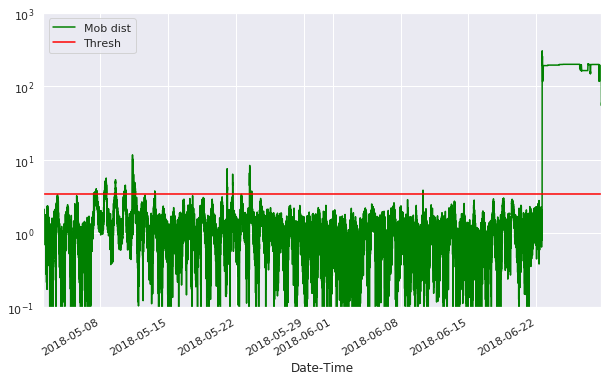

In [0]:
anomaly_alldata.plot(logy=True, figsize = (10,6), ylim = [1e-1,1e3], color = ['green','red'])

In [0]:
seed(10)
set_random_seed(10)
act_func = 'elu'

# Input layer:
model=Sequential()
# First hidden layer, connected to input vector X. 
model.add(Dense(10,activation=act_func,
                kernel_initializer='glorot_uniform',
                kernel_regularizer=regularizers.l2(0.0),
                input_shape=(X_train.shape[1],)
               )
         )

model.add(Dense(2,activation=act_func,
                kernel_initializer='glorot_uniform'))

model.add(Dense(10,activation=act_func,
                kernel_initializer='glorot_uniform'))

model.add(Dense(X_train.shape[1],
                kernel_initializer='glorot_uniform'))

model.compile(loss='mse',optimizer='adam')

# Train model for 100 epochs, batch size of 10: 
NUM_EPOCHS=100
BATCH_SIZE=10

Instructions for updating:
Colocations handled automatically by placer.


In [0]:
history=model.fit(np.array(X_train),np.array(X_train),
                  batch_size=BATCH_SIZE, 
                  epochs=NUM_EPOCHS,
                  validation_split=0.05,
                  verbose = 1)

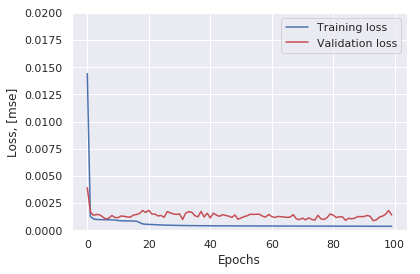

In [0]:
plt.plot(history.history['loss'],
         'b',
         label='Training loss')
plt.plot(history.history['val_loss'],
         'r',
         label='Validation loss')
plt.legend(loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Loss, [mse]')
plt.ylim([0,.02])
plt.show()

(0.0, 0.5)

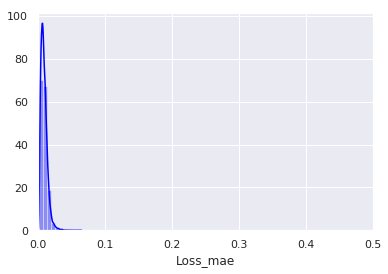

In [0]:
X_pred = model.predict(np.array(X_train))
X_pred = pd.DataFrame(X_pred, 
                      columns=X_train.columns)
X_pred.index = X_train.index

scored = pd.DataFrame(index=X_train.index)
scored['Loss_mae'] = np.mean(np.abs(X_pred-X_train), axis = 1)
plt.figure()
sns.distplot(scored['Loss_mae'],
             bins = 10, 
             kde= True,
            color = 'blue');
plt.xlim([0.0,.5])

In [0]:
X_pred = model.predict(np.array(X_test))
X_pred = pd.DataFrame(X_pred, 
                      columns=X_test.columns)
X_pred.index = X_test.index

scored = pd.DataFrame(index=X_test.index)
scored['Loss_mae'] = np.mean(np.abs(X_pred-X_test), axis = 1)
scored['Threshold'] = 0.3
scored['Anomaly'] = scored['Loss_mae'] > scored['Threshold']
scored.head()

,Loss_mae,Threshold,Anomaly
Date-Time,,,
2018-06-21 20:18:00,0.027533,0.3,False
2018-06-21 20:21:00,0.019371,0.3,False
2018-06-21 20:24:00,0.032605,0.3,False
2018-06-21 20:27:00,0.025059,0.3,False
2018-06-21 20:30:00,0.014181,0.3,False


In [0]:
X_pred_train = model.predict(np.array(X_train))
X_pred_train = pd.DataFrame(X_pred_train, 
                      columns=X_train.columns)
X_pred_train.index = X_train.index

scored_train = pd.DataFrame(index=X_train.index)
scored_train['Loss_mae'] = np.mean(np.abs(X_pred_train-X_train), axis = 1)
scored_train['Threshold'] = 0.3
scored_train['Anomaly'] = scored_train['Loss_mae'] > scored_train['Threshold']
scored = pd.concat([scored_train, scored])

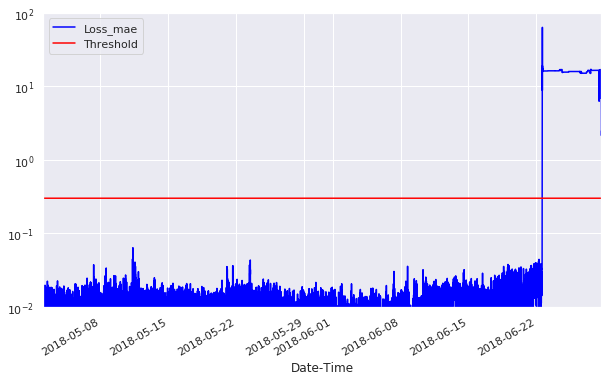

In [0]:
scored.plot(logy=True,  figsize = (10,6), ylim = [1e-2,1e2], color = ['blue','red'])

(0.0, 0.5)

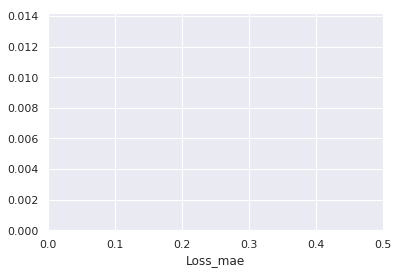

In [0]:
X_pred = model.predict(np.array(dataset_test))
X_pred = pd.DataFrame(X_pred, 
                      columns=X_train.columns)
X_pred.index = dataset_test.index

scored = pd.DataFrame(index=dataset_test.index)
scored['Loss_mae'] = np.mean(np.abs(X_pred-dataset_test), axis = 1)
plt.figure()
sns.distplot(scored['Loss_mae'],
             bins = 10, 
             kde= True,
            color = 'blue');
plt.xlim([0.0,.5])

In [0]:
X_pred = model.predict(np.array(dataset_test))
X_pred = pd.DataFrame(X_pred, 
                      columns=X_test.columns)
X_pred.index = dataset_test.index

scored = pd.DataFrame(index=dataset_test.index)
scored['Loss_mae'] = np.mean(np.abs(X_pred-dataset_test), axis = 1)
scored['Threshold'] = 0.3
scored['Anomaly'] = scored['Loss_mae'] > scored['Threshold']
scored.head()

,Loss_mae,Threshold,Anomaly
Date-Time,,,
2018-06-21 20:18:00,836.596108,0.3,True
2018-06-21 20:21:00,836.810419,0.3,True
2018-06-21 20:24:00,836.555570,0.3,True
2018-06-21 20:27:00,836.460624,0.3,True
2018-06-21 20:30:00,836.662998,0.3,True


In [0]:
X_pred_train = model.predict(np.array(dataset_test))
X_pred_train = pd.DataFrame(X_pred_train, 
                      columns=dataset_test.columns)
X_pred_train.index = dataset_test.index

scored_train = pd.DataFrame(index=dataset_test.index)
scored_train['Loss_mae'] = np.mean(np.abs(X_pred_train-dataset_test), axis = 1)
scored_train['Threshold'] = 0.3
scored_train['Anomaly'] = scored_train['Loss_mae'] > scored_train['Threshold']
scored = pd.concat([scored_train, scored])

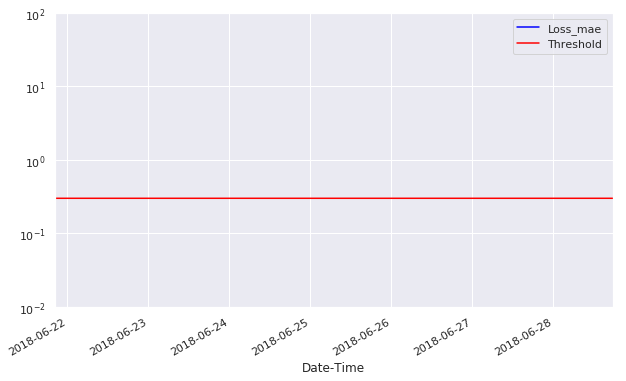

In [0]:
scored.plot(logy=True,  figsize = (10,6), ylim = [1e-2,1e2], color = ['blue','red'])